In [1]:
import numpy as np
import matplotlib.pyplot as plt


def read_latency_data(file_path, ignore):
    with open(file_path, "r") as file:
        latencies = [int(line.strip()) for line in file if line.strip().isdigit()]
    n_ignore = int(len(latencies) * ignore)
    latencies = latencies[n_ignore:]
    return latencies


def plot_cdf(data, title):
    data = np.sort(data)
    cdf = np.arange(1, len(data) + 1) / len(data)

    plt.figure(figsize=(8, 6))
    plt.plot(data, cdf, marker=".", linestyle="none")
    plt.title(title)
    plt.xlabel("Latency (microseconds)")
    plt.ylabel("CDF")
    plt.grid(True)
    plt.show()

    for pctl in [50, 90, 99]:
        print(f"p{pctl}: {np.percentile(data, pctl).astype(int)}")

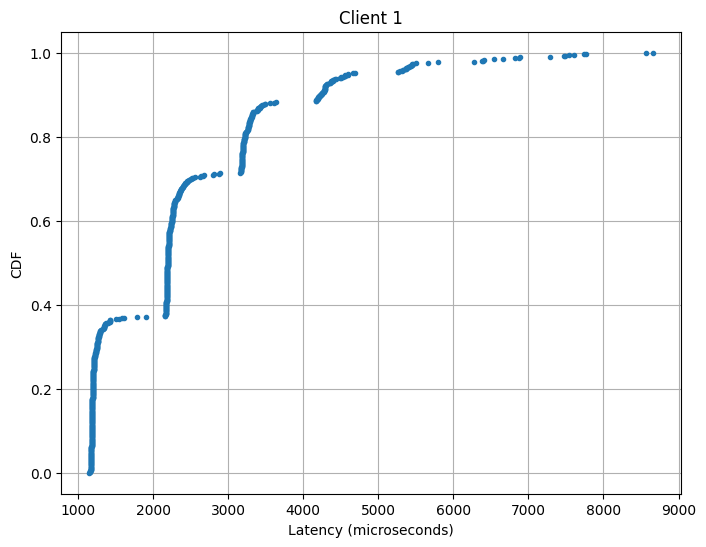

p50: 2193
p90: 4231
p99: 7242


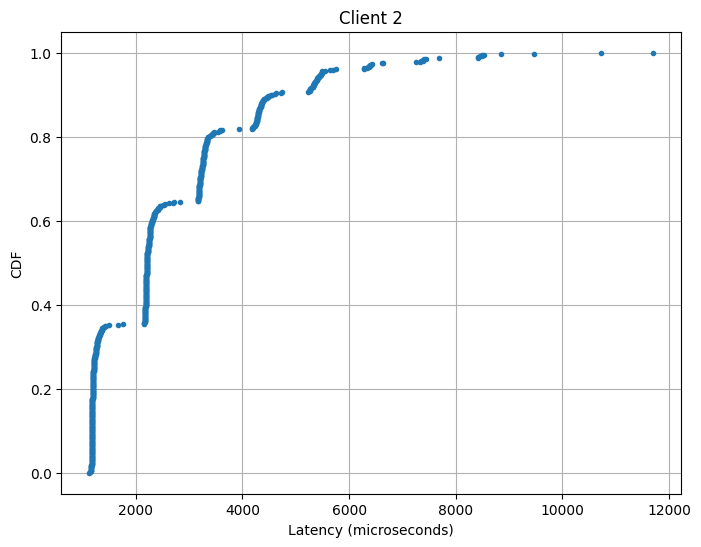

p50: 2211
p90: 4546
p99: 8419


In [2]:
file_path = "client1.csv"
plot_cdf(read_latency_data(file_path, ignore=0.2), "Client 1")

file_path = "client2.csv"
plot_cdf(read_latency_data(file_path, ignore=0.2), "Client 2")